# Linear Regression with Easy Explanations

This notebook has two parts:
1. Basic Linear Regression on Salary data
2. A second dataset example with preprocessing + pipeline

## Easy English Terms (Quick Glossary)

- Preprocessing: cleaning and preparing data before training.
- SimpleImputer: fills missing values (empty data).
- Outlier: a value much bigger or smaller than the rest.
- Outlier Detection: finding unusual values.
- IQR (Interquartile Range): middle spread of data, used to detect outliers.
- MinMaxScaler: scales numbers to a fixed range, usually [0, 1].
- StandardScaler: rescales data so features are on a similar scale.
- Pipeline: a fixed sequence of steps (preprocess -> model).
- ColumnTransformer: applies different preprocessing to numeric and categorical columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [11]:
X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

In [28]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [12]:
print(y)

[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


## Step: Split Data into Train and Test Sets

We split data into two parts:
- Training data: used to teach the model
- Testing data: used to check model performance on unseen data

This helps us measure whether the model generalizes well.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Step: Train the Linear Regression Model

Linear Regression learns the best-fit straight line between:
- Input feature: Years of Experience
- Output target: Salary

In [16]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step: Predict on Test Data

After training, we use the model to predict salary values for test inputs.

In [17]:
y_pred = regressor.predict(X_test)

In [18]:
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

In [22]:
regressor.score(X_test, y_test)

0.988169515729126

## Important Scores (Basic Salary Model)

These scores tell how good the model is:
- MAE: average absolute error
- MSE: average squared error
- RMSE: error in original salary units
- R2: goodness of fit (closer to 1 is better)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_basic = mean_absolute_error(y_test, y_pred)
mse_basic = mean_squared_error(y_test, y_pred)
rmse_basic = np.sqrt(mse_basic)
r2_basic = r2_score(y_test, y_pred)

basic_scores_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Value': [mae_basic, mse_basic, rmse_basic, r2_basic]
})

basic_scores_df


mae_basic, mse_basic, rmse_basic, r2_basic

(2446.1723690465055,
 12823412.298126549,
 np.float64(3580.979237321343),
 0.988169515729126)

## Score Graphs (Basic Salary Model)

The charts below show:
1. Actual vs Predicted values
2. Error pattern (residual plot)
3. Score bars (MAE, RMSE, R2)

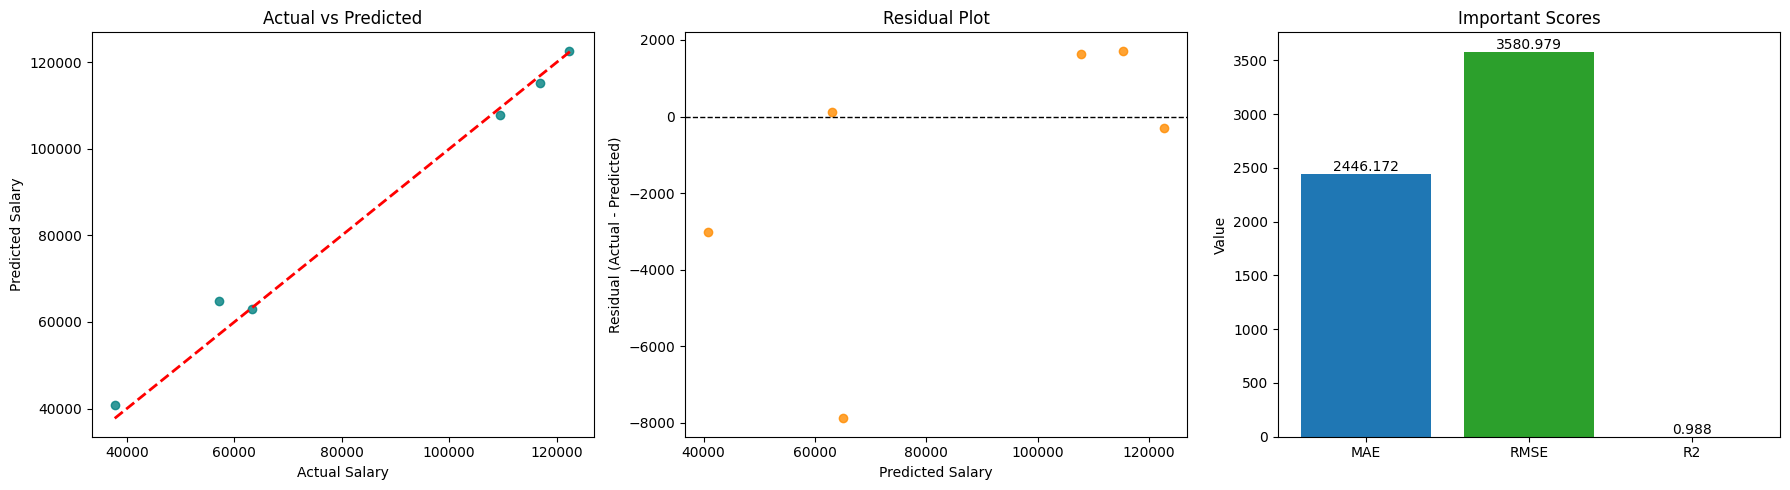

In [24]:
residuals_basic = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='teal', alpha=0.8)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual Salary')
axes[0].set_ylabel('Predicted Salary')

# 2) Residual plot
axes[1].scatter(y_pred, residuals_basic, color='darkorange', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted Salary')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Key score bars
score_names = ['MAE', 'RMSE', 'R2']
score_values = [mae_basic, rmse_basic, r2_basic]
axes[2].bar(score_names, score_values, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
axes[2].set_title('Important Scores')
axes[2].set_ylabel('Value')
for i, v in enumerate(score_values):
    axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Step: Make a Single Prediction

Example: Predict salary for 12 years of experience.

We pass [[12]] (double brackets) because scikit-learn expects a 2D input format: [samples, features].

In [29]:
regressor.predict([[2.3]])

array([48199.02194211])

## Note

The `predict()` method always expects a 2D array.
So even for one value (12 years), we provide `[[12]]`, not `[12]`.

## Step: Visualize the Training Set Result

Red dots are actual values and the blue line is the model prediction line.

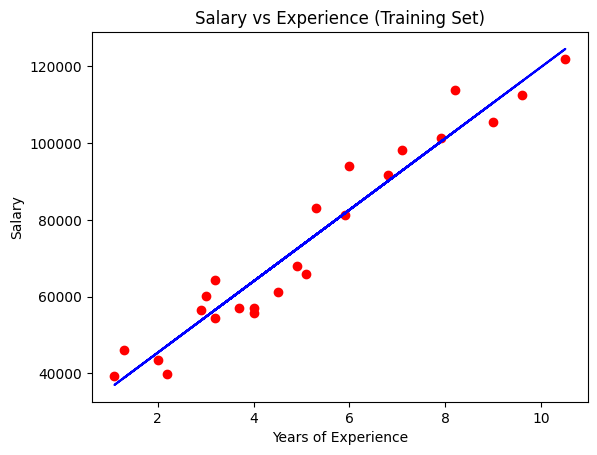

In [30]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (Training Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

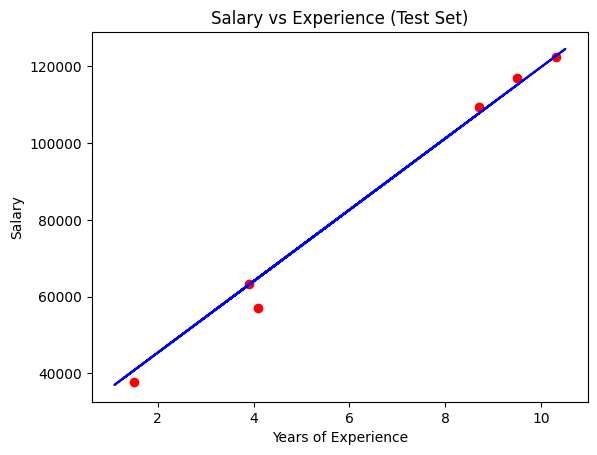

In [31]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

# Part 2: Another Dataset with Preprocessing and Pipeline
# In this section, we use 50_Startups.csv and build a full workflow.

In [40]:
startup_df = pd.read_csv('50_Startups.csv')
print('Shape:', startup_df.shape)
print('\nColumns:', startup_df.columns.tolist())
startup_df.head()

Shape: (50, 5)

Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Step 1: Data Check

We inspect missing values and basic information before training.

In [41]:
print(startup_df.info())
print('\nMissing values in each column:')
print(startup_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        48 non-null     float64
 1   Administration   48 non-null     float64
 2   Marketing Spend  47 non-null     float64
 3   State            47 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB
None

Missing values in each column:
R&D Spend          2
Administration     2
Marketing Spend    3
State              3
Profit             0
dtype: int64


## Step 2: Outlier Detection using IQR

Easy idea:
- Q1 is 25% point, Q3 is 75% point
- IQR = Q3 - Q1
- Outliers are values outside:
  - lower = Q1 - 1.5 * IQR
  - upper = Q3 + 1.5 * IQR

In [34]:
q1 = startup_df['Profit'].quantile(0.25)
q3 = startup_df['Profit'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (startup_df['Profit'] < lower) | (startup_df['Profit'] > upper)
print(f'Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}')
print(f'Lower bound: {lower:.2f}, Upper bound: {upper:.2f}')
print(f'Outliers found in Profit: {outlier_mask.sum()}')

Q1: 90138.90, Q3: 139765.98, IQR: 49627.07
Lower bound: 15698.29, Upper bound: 214206.59
Outliers found in Profit: 1


## Step 3: Build a Preprocessing + Model Pipeline

What this pipeline does:
- Numeric columns: fill missing values with median, then scale
- Categorical columns: fill missing values with most frequent value, then one-hot encode
- Final step: train Linear Regression

This is safer and cleaner than manual preprocessing.

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X2 = startup_df.drop('Profit', axis=1)
y2 = startup_df['Profit']

# Detect column types
num_features = X2.select_dtypes(include=['number']).columns
cat_features = X2.select_dtypes(exclude=['number']).columns

# Numeric preprocessing: impute + scale
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing: impute + one-hot encode
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine preprocessing for both types
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

# Complete model pipeline
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [36]:
model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Step 4: Train, Predict, and Evaluate

We train the pipeline on training data and evaluate with:
- MAE: average absolute error
- RMSE: root mean squared error
- R2: goodness of fit (closer to 1 is better)

In [43]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_pipeline.fit(X2_train, y2_train)
y2_pred = model_pipeline.predict(X2_test)

mae = mean_absolute_error(y2_test, y2_pred)
rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2 = r2_score(y2_test, y2_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

results_df = pd.DataFrame({
    'Actual': y2_test.values,
    'Predicted': y2_pred
})
results_df.head()

MAE: 6708.53
RMSE: 8580.49
R2 Score: 0.9091


,Actual,Predicted
0,134307.35,126814.691204
1,81005.76,83617.203192
2,99937.59,97932.020415
3,64926.08,46549.215157
4,125370.37,128992.168065


## Important Scores and Graphs (50_Startups Pipeline)

We now visualize how well the pipeline model performs using:
- Actual vs Predicted plot
- Residual plot
- Key score bars (MAE, RMSE, R2)

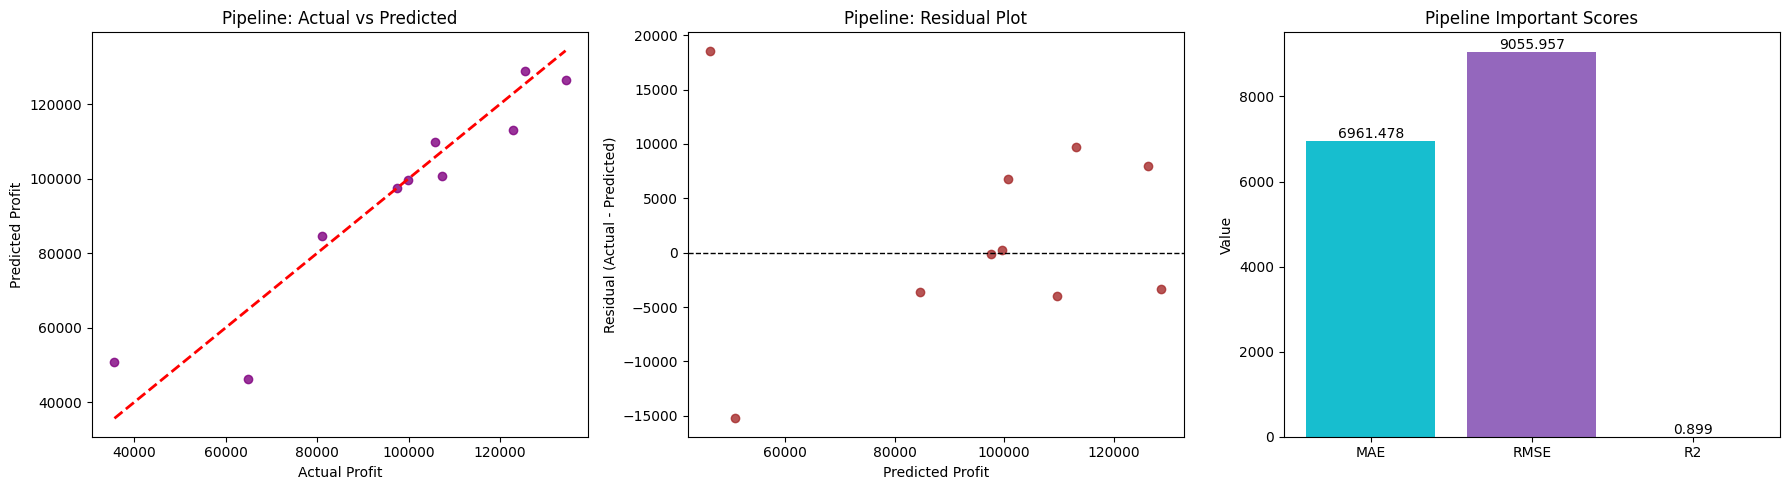

In [38]:
residuals_pipeline = y2_test.values - y2_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Actual vs Predicted
axes[0].scatter(y2_test, y2_pred, color='purple', alpha=0.8)
min_val2 = min(y2_test.min(), y2_pred.min())
max_val2 = max(y2_test.max(), y2_pred.max())
axes[0].plot([min_val2, max_val2], [min_val2, max_val2], 'r--', linewidth=2)
axes[0].set_title('Pipeline: Actual vs Predicted')
axes[0].set_xlabel('Actual Profit')
axes[0].set_ylabel('Predicted Profit')

# 2) Residual plot
axes[1].scatter(y2_pred, residuals_pipeline, color='brown', alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Pipeline: Residual Plot')
axes[1].set_xlabel('Predicted Profit')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# 3) Key score bars
score_names2 = ['MAE', 'RMSE', 'R2']
score_values2 = [mae, rmse, r2]
axes[2].bar(score_names2, score_values2, color=['#17becf', '#9467bd', '#bcbd22'])
axes[2].set_title('Pipeline Important Scores')
axes[2].set_ylabel('Value')
for i, v in enumerate(score_values2):
    axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Step 5: Optional MinMaxScaler Example

If you want values between 0 and 1, use MinMaxScaler instead of StandardScaler for numeric columns.

In [44]:
from sklearn.preprocessing import MinMaxScaler

num_pipeline_minmax = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ]
)

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_minmax, num_features),
        ('cat', cat_pipeline, cat_features)
    ]
)

model_pipeline_minmax = Pipeline(
    steps=[
        ('preprocessor', preprocessor_minmax),
        ('model', LinearRegression())
    ]
)

model_pipeline_minmax.fit(X2_train, y2_train)
y2_pred_minmax = model_pipeline_minmax.predict(X2_test)

print('MinMax Pipeline R2:', round(r2_score(y2_test, y2_pred_minmax), 4))

MinMax Pipeline R2: 0.9091
